In [5]:
import numpy as np
from utils import analytic, tf, lowpass

## Άσκηση — Διαμόρφωση SSB (Single Sideband Modulation)

Είναι καλή ιδέα να τρέξετε την άσκηση $\texttt{Ex-DSBSCmodulation}$ ώστε να μπορείτε να συγκρίνετε με αυτή. 

Οι δύο πλευρικές ζώνες της DSB-SC διαμόρφωσης μεταφέρουν την **ίδια** πληροφορία, άρα η μία είναι περιττή. 

Η διαμόρφωση **SSB** μεταδίδει μόνο μία πλευρική ζώνη, μειώνοντας το συνολικό εύρος ζώνης στο μισό ($W_B=f_m$) και εξοικονομώντας ισχύ μετάδοσης!

Στην άσκηση αυτή, χρησιμοποιούμε τη **μέθοδο μετατόπισης φάσης (phasing / Hartley)**, που στηρίζεται στον μετασχηματισμό **Hilbert** $\hat m(t)$ του μηνύματος:

$$s_{\text{SSB}}(t) = \tfrac{A_c}{2}\big[\,m(t)\cos(\omega_c t) \mp \hat m(t)\sin(\omega_c t)\,\big] \tag{1}$$

όπου το πρόσημο $-$ δίνει την **άνω** πλευρική (USB) και το $+$ την **κάτω** (LSB). 

Θυμηθείτε ότι ο μετασχηματισμός Hilbert μετατοπίζει κάθε συχνότητα κατά $-90^\circ$: για $m(t)=A_m\cos(\omega_m t)$ είναι $\hat m(t)=A_m\sin(\omega_m t)$.

Ας δουλέψουμε με την **ανω πλευρική (USB).** Αντικαθιστώντας στη Σχέση (1) με πρόσημο $-$:

$$s_{\text{USB}}(t) = \tfrac{A_c}{2}\big[\cos\omega_m t\cos\omega_c t - \sin\omega_m t\sin\omega_c t\big] = \tfrac{A_c A_m}{2}\cos((\omega_c\!+\!\omega_m)t) \tag{2}$$

δηλαδή **μία μόνο** φασματική γραμμή στα $f_c+f_m=1100$ Hz.

Για την **αποδιαμόρφωση (σύγχρονη)**, έχουμε

$$s_{\text{USB}}(t)\cos(\omega_c t)=\tfrac{A_c A_m}{4}\cos(\omega_m t) + \tfrac{A_c A_m}{4}\cos((2\omega_c\!+\!\omega_m)t) \tag{3}$$

και ένα χαμηλοπερατό φίλτρο αφήνει τον όρο $\tfrac{A_c A_m}{4}\cos(\omega_m t)\propto m(t)$.

### i. Μήνυμα, φέρον και μετασχηματισμός Hilbert

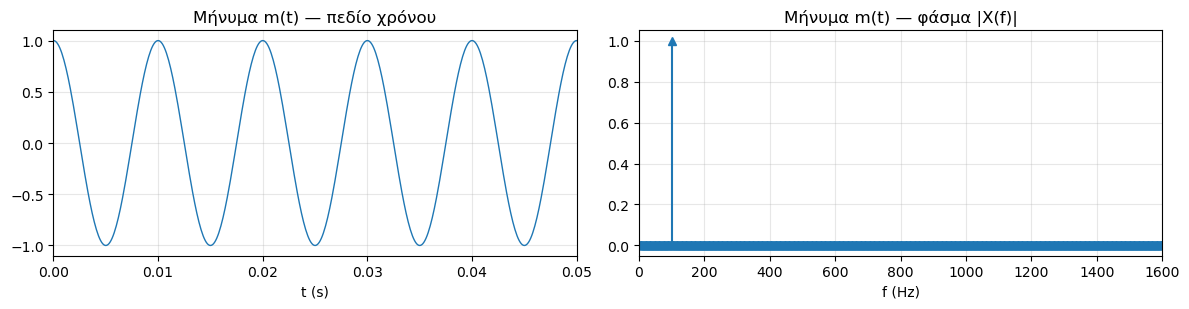

Έλεγχος: mhat ~ Am*sin(wm t)?  Το μέγιστο σφάλμα ισούται με 3.116951141635127e-14


In [3]:
# ----- Παράμετροι (κοινές) -----
fs = 10000          # συχνότητα δειγματοληψίας (Hz)
N  = 4000           # πλήθος δειγμάτων (0.4 s)
t  = np.arange(N)/fs
fm = 100            # συχνότητα μηνύματος (Hz)
fc = 1000           # συχνότητα φέροντος (Hz)
Am = 1.0            # πλάτος μηνύματος
Ac = 1.0            # πλάτος φέροντος
wm = 2*np.pi*fm
wc = 2*np.pi*fc

m = Am*np.cos(wm*t)         # μήνυμα (ημιτονοειδές)
carrier = Ac*np.cos(wc*t)   # φέρον

mhat = np.imag(analytic(m))     # Hilbert του m -> Am*sin(wm t)

tf(m, fs, 'Μήνυμα m(t)')
print('Έλεγχος: mhat ~ Am*sin(wm t)?  Το μέγιστο σφάλμα ισούται με',
      np.max(np.abs(mhat[200:N-200] - Am*np.sin(wm*t)[200:N-200])))

### ii. Παραγωγή του σήματος SSB

Υλοποιήστε απευθείας τη Σχέση (1):

**Διαμόρφωση USB** — το φάσμα έχει **μία μόνο** γραμμή στα $1100$ Hz (η κάτω πλευρική εξαλείφθηκε).

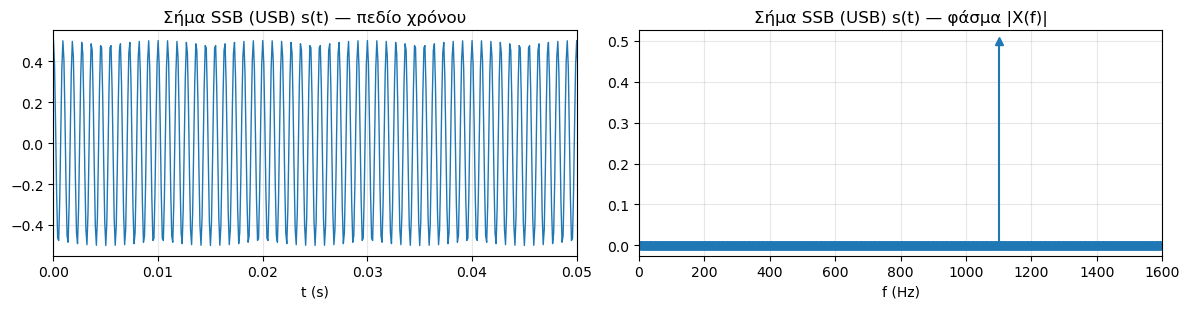

In [4]:
s = 0.5*Ac*( m*np.cos(wc*t) - mhat*np.sin(wc*t) ) # INSERT CODE HERE

tf(s, fs, 'Σήμα SSB (USB) s(t)')

### iii. Σύγχρονη αποδιαμόρφωση (Σχέση 3)

Για την αποδιαμόρφωση, πρέπει να πολλαπλασιάσουμε το USB σήμα με ένα συνημίτονο ίδιας συχνότητας με το φέρον, και να εφαρμόσουμε κατάλληλο χαμηλοπερατό φίλτρο. Δείτε παρακάτω:

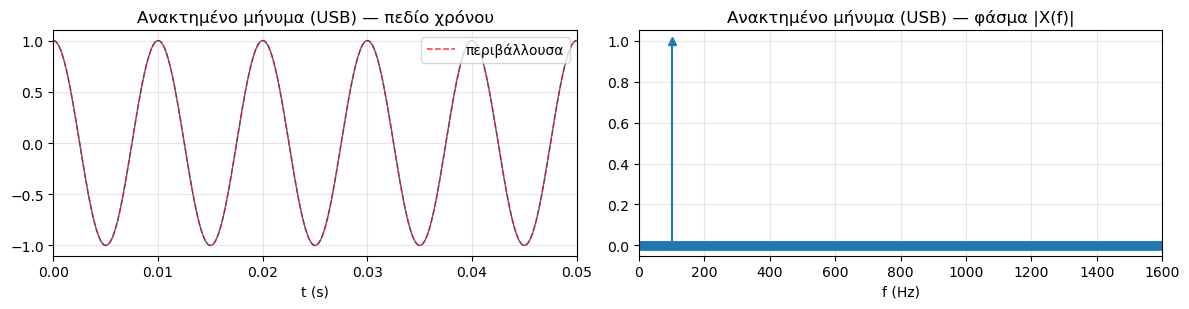

To μέγιστο σφάλμα ανάκτησης ισούται με 1.654e-13


In [7]:
v = s * np.cos(wc*t)
rec = lowpass(v, 1.5*fm, fs)
rec = rec / (Ac*Am/4)          # κανονικοποίηση -> m(t)

tf(rec, fs, 'Ανακτημένο μήνυμα (USB)', ref=m)

sl = slice(200, N-200)
print(f'To μέγιστο σφάλμα ανάκτησης ισούται με {np.max(np.abs(rec[sl]-m[sl])):.3e}')

### Παρατηρήσεις

Η μέθοδος μετατόπισης φάσης δίνει καθαρή άνω πλευρική: το φάσμα του διαμορφωμένου σήματος έχει **μία** γραμμή στα $1100$ Hz, με το εύρος ζώνης μειωμένο στο μισό ($f_m$ αντί $2f_m$) σε σχέση με AM/DSB-SC. Η σύγχρονη ανίχνευση ανακτά το μήνυμα με αμελητέο σφάλμα. 

Η SSB είναι η πιο οικονομική τεχνική σε εύρος ζώνης και ισχύ, αλλά απαιτεί (α) ακριβή μετασχηματισμό Hilbert κατά τη διαμόρφωση και (β) συγχρονισμένο δέκτη - η ακρίβεια φάσης είναι κρίσιμη, αλλά εμείς πολύ απλά την αγνοήσαμε στο παραπάνω παράδειγμα. 

Σημειώνουμε ότι η SSB δυσκολεύεται με σήματα που έχουν σημαντικό περιεχόμενο κοντά στο $f=0$ (π.χ. video), κάτι που ιστορικά οδήγησε στην VSB, την οποία μπορείτε να μελετήσετε σε άλλο notebook.

---
---